# Value at Risk Estimation and Backtesting for SENSEX Portfolios: Integrating Extreme Value Theory and GARCH Models

# Objective

- Estimate Value at Risk (VaR) for a portfolio constructed using SENSEX constituent stocks weighted as per index composition.
- Evaluate and compare multiple VaR estimation techniques:  
  Historical Simulation, Variance-Covariance, Monte Carlo, GARCH(1,1), EVT (Generalized Pareto Distribution) , and GARCH+EVT (hybrid approach).
- Perform model backtesting using violation counts and violation ratio, Kupiec’s Proportion of Failure (POF) Test, and Basel Traffic Light Framework
- Analyze model performance in both *calm* (2017) and *stressed* (2020) market conditions.
- - Analyze return distribution and model tail risk using: Goodness-of-fit comparisons for Normal vs. Student-t distribution and GPD fitting for the left-tail of extreme losses


# Data Preparation

- Downloaded daily adjusted closing prices for all 30 SENSEX stocks from Yahoo Finance (2015–2024).
- Portfolio returns constructed using SENSEX weights (as of September 2024).
- Log returns computed to form the return series.

# Market Regime Segmentation

- Volatility-based segmentation:
  - **Calm Period**: January 2017 – January 2018  
  - **Stressed Period**: February 2020 – February 2021
- Used 30-day rolling standard deviation to classify periods.

# Return Distribution Fitting

- In the **calm period**, returns are near-normal:
  - Skewness = 0.02, Kurtosis = 0.18  
  - $R^2_{\text{Normal}} \approx 0.99$, $R^2_{\text{t}} \approx 0.94$

- In the **stressed period**, returns show heavy tails:
  - Skewness = -1.71, Kurtosis = 12.05  
  - $R^2_{\text{Normal}} \approx 0.79$, $R^2_{\text{t}} \approx 0.88$

- For the full period (2015–2024):
  - Student-t distribution outperforms Normal ($R^2$ = 0.86 vs 0.83)
  - Kurtosis = 21.8 confirms extreme tail behavior

# Tail Modeling with EVT

- Applied Generalized Pareto Distribution (GPD) on losses beyond 5th percentile.
- $R^2_{\text{GPD}} \approx 0.90$
- QQ plot, ECDF, and mean excess function support GPD as a good tail model.

# VaR Estimation

- Computed 1-day VaR using a 250-day rolling window.
- Confidence levels used: 90%, 95%, 97%, 99%
- Applied the following methods:
  - Historical Simulation  
  - Variance-Covariance (Normal)  
  - Monte Carlo Simulation  
  - EWMA  
  - GARCH(1,1)  
  - EVT  
  - GARCH + EVT

# Backtesting Results

## Calm Period (2017)

- All models performed well under normal conditions.
- Violation Ratios close to 1 for most methods.
- Kupiec test p-values mostly > 0.05 (no statistical rejection).
- GARCH and Historical Simulation had lowest violations.

## Stressed Period (2020)

- All models had poor performance at 99% level.
- EWMA and GARCH entered **Basel Red Zone**.
- GARCH+EVT had only 6 violations (vs. 3 expected), p-value = 0.06 $\to$ **Best performing model**.

| Method               | Violations | Basel Zone |
|----------------------|------------|------|
| Historical           | 8         | $\colorbox{yellow}{Yellow Zone}$ |
| Variance-Covariance  | 9          | $\colorbox{yellow}{Yellow Zone}$ |
| Monte Carlo          | 9         | $\colorbox{yellow}{Yellow Zone}$ |
| EWMA                 | 10         | $\colorbox{red}{Red Zone }$ |
| GARCH                | 12         | $\colorbox{red}{Red Zone }$ |
| EVT                  | 8          | $\colorbox{yellow}{Yellow Zone}$ |
| GARCH + EVT          | 6          | $\colorbox{yellow}{Yellow Zone}$ |

# Final Takeaways

- Traditional VaR methods are acceptable in calm markets but fail to capture extreme risk during stress.
- Student-t distribution and GPD provide superior fit for fat-tailed returns.
- GARCH + EVT offers the best trade-off between conditional volatility modeling and tail risk estimation.
- **EVT-enhanced models are more robust and better aligned with regulatory expectations under Basel guidelines.**


Required packages

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf

import scipy.linalg
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats as stats
from scipy.stats import chi2, norm, t, genpareto, skew, kurtosis

from arch import arch_model

from statsmodels.distributions.empirical_distribution import ECDF
import statsmodels.api as sm

from sklearn.metrics import r2_score

np.random.seed(100)

## Data processing

We consider a portfolio with the same weightage as the SENSEX index (top 30 companies in the BSE).

In [2]:
# The following data is downloaded from the BSE website. The data contains SENSEX stocks and weightage as on September 30, 2024. 
sensex_data=pd.read_csv("Sensex_data.csv")
sensex_data.head()

,Company Name,Stock Symbol (NSE),Weightage (%)
0,Adani Ports & Special Economic Zone Ltd,ADANIPORTS,1.09
1,Asian Paints Ltd.,ASIANPAINT,1.54
2,Axis Bank Ltd.,AXISBANK,3.61
3,Bajaj Finserv Ltd.,BAJAJFINSV,1.10
4,Bajaj Finance Ltd.,BAJFINANCE,2.21


In [3]:
sensex_stocks=sensex_data["Stock Symbol (NSE)"].to_numpy()
# ".NS" needs to be added as Yahoo Finance downloads the stock data in this way (".NS" represents NSE)
sensex_stocks=[symbol+".NS" for symbol in sensex_stocks]  
sensex_weightage=pd.to_numeric(sensex_data["Weightage (%)"]).to_numpy()
sensex_weightage=sensex_weightage/sensex_weightage.sum()  # So that the sum of weights is 1


We use the adjusted close price of each stocks for last 10 years (2015-2024) saved in SENSEX stocks return.csv file. Which can be downloaded from the folowing command too.

stock_data=yf.download(ticker_set, start=start_date, end=end_date,auto_adjust=False)['Adj Close']

In [4]:
stock_data=pd.read_csv("SENSEX stocks return.csv", parse_dates=["Date"], index_col='Date')
stock_data.index = pd.to_datetime(stock_data.index)
stock_return=np.log(stock_data/stock_data.shift(1)).dropna()  # We consider the log return
stock_return

,ADANIPORTS.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATAMOTORS.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,-0.000626,0.033988,0.022117,-0.008547,-0.016116,0.005907,-0.000965,0.013821,-0.003302,0.027989,...,0.011963,-0.002650,0.003973,0.004914,0.026431,0.015457,0.013229,0.004883,0.007868,0.029459
2015-01-05,0.013838,-0.000064,0.006299,-0.013376,-0.002617,-0.022439,-0.016963,-0.008479,0.005738,0.002068,...,0.001080,-0.011014,-0.007962,0.000605,0.023176,0.014382,-0.015313,-0.016825,0.008066,0.002040
2015-01-06,-0.006040,-0.024161,-0.036400,-0.023391,-0.002594,-0.007875,-0.027070,-0.015689,0.018763,-0.043344,...,-0.022571,-0.046447,-0.041955,-0.022260,-0.043706,-0.049691,-0.037563,-0.010784,-0.034805,-0.028461
2015-01-07,-0.002333,0.019894,-0.000802,-0.000854,0.020155,0.002397,-0.024048,0.002914,0.034508,-0.027411,...,0.014257,0.021534,0.000833,0.001545,-0.015172,-0.019354,-0.011883,-0.004683,0.005085,-0.003958
2015-01-08,0.041034,0.061135,0.006596,0.048653,-0.001704,0.017176,0.022876,0.020788,0.018716,0.026835,...,0.004346,-0.014443,0.015538,0.011052,0.036093,0.015437,0.010738,0.016598,-0.004549,0.025022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-23,0.007876,-0.001381,0.006788,-0.003990,0.002691,0.005561,-0.004378,0.016515,0.002140,0.006499,...,-0.001585,0.014006,0.011205,0.003174,-0.002558,0.007295,-0.002882,0.015507,0.012054,0.004350
2024-12-24,-0.008088,0.002104,-0.000232,0.000735,-0.008556,-0.001892,-0.003184,-0.001612,-0.001433,0.000347,...,-0.016630,0.000368,-0.011144,0.002422,0.019064,-0.009430,0.005085,-0.004389,-0.012903,-0.007195
2024-12-26,0.050915,-0.009502,-0.002041,-0.003361,0.001108,0.009801,0.002001,-0.004096,-0.001200,0.000077,...,0.000645,-0.005083,0.000492,0.012212,0.006365,-0.000143,-0.002491,-0.003643,-0.009092,0.006153


In [5]:
portfolio_return = stock_return @ sensex_weightage

## Portfolio returns fit

Identifying calm and stressed period

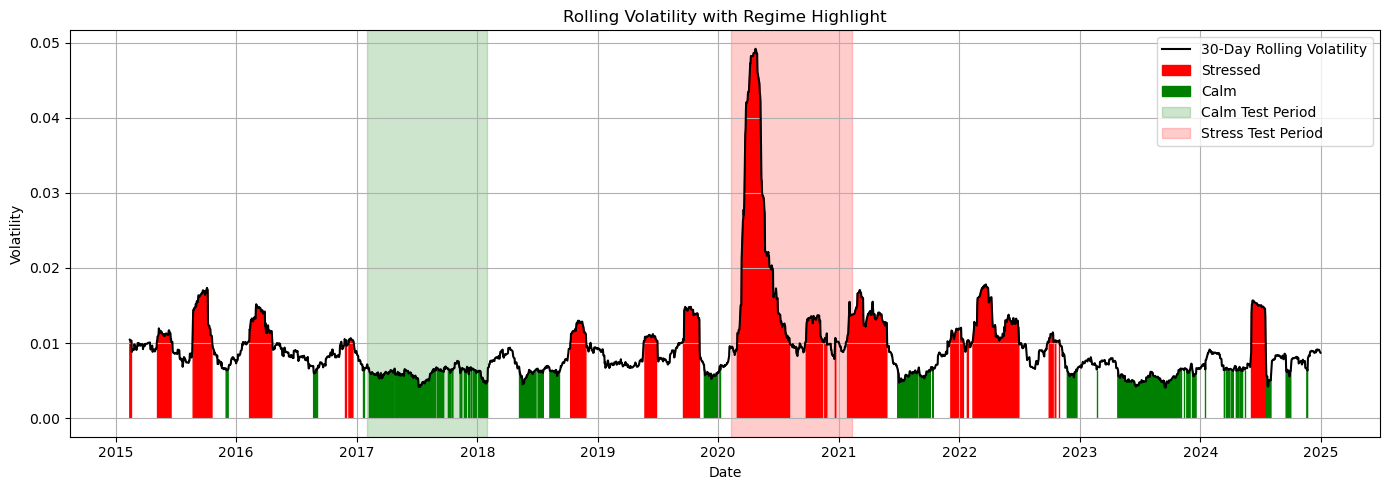

In [6]:

vol = portfolio_return.rolling(30).std()
threshold_high = vol.quantile(0.75)
threshold_low = vol.quantile(0.25)

regime = pd.Series(index=portfolio_return.index, dtype='str')
regime[vol >= threshold_high] = 'stress'
regime[vol <= threshold_low] = 'calm'
regime.fillna('neutral', inplace=True)


plt.figure(figsize=(14, 5))
plt.plot(vol, label='30-Day Rolling Volatility', color='black')

plt.fill_between(vol.index, 0, vol, where=(regime == 'stress'), color='red', label='Stressed')
plt.fill_between(vol.index, 0, vol, where=(regime == 'calm'), color='green', label='Calm')



plt.axvspan(pd.Timestamp("2017-01-31"), pd.Timestamp("2018-01-31"),
            color='green', alpha=0.2, label='Calm Test Period')

plt.axvspan(pd.Timestamp("2020-02-10"), pd.Timestamp("2021-02-10"),
            color='red', alpha=0.2, label='Stress Test Period')


plt.title("Rolling Volatility with Regime Highlight")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Roughly, 2017 year is a calm period and 2020 year as stressed period.

In [7]:
returns_calm = (stock_return.loc[:'2018-01-31']).tail(500)
returns_stress = (stock_return.loc[:'2021-02-10']).tail(500)
portfolio_return_calm = returns_calm @ sensex_weightage
portfolio_return_stress = returns_stress @ sensex_weightage

In [8]:
def plot_return(returns):
    cumulative_return = (returns + 1).cumprod() - 1

    plt.figure(figsize=(14, 4))

    plt.subplot(1, 2, 1)
    plt.plot(returns, color='blue')
    plt.title("Daily (Log) Returns")
    plt.xlabel("Date")
    plt.ylabel("(Log) Return")
    plt.grid(True)


    plt.subplot(1, 2, 2)
    plt.plot(cumulative_return, color='green')
    plt.title("Cumulative Return")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Return")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

== Return and cumulative return is calm period (2016-01-25 to 2018-01-31)==


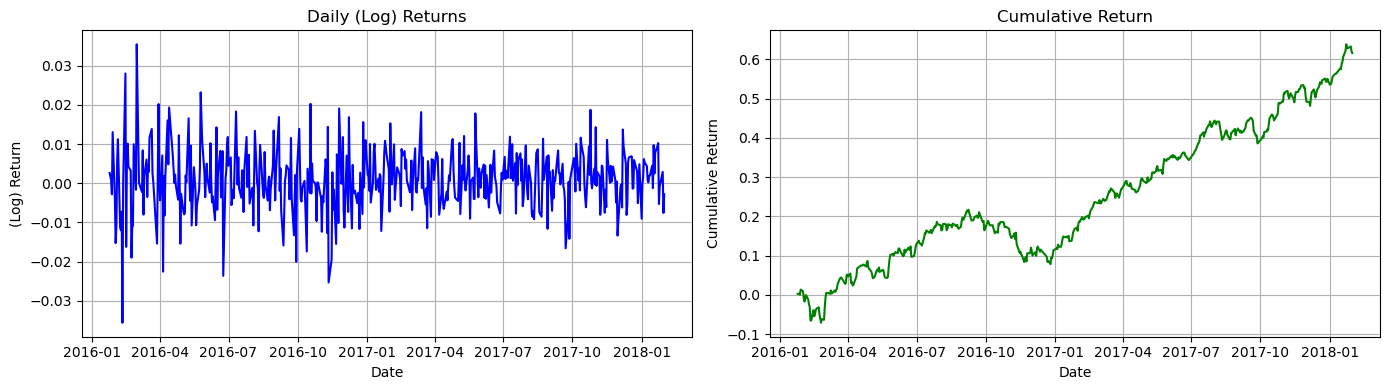

In [9]:
print("== Return and cumulative return is calm period (2016-01-25 to 2018-01-31)==")
plot_return(portfolio_return_calm)

== Return and cumulative return is stress period (2019-01-31 to 2021-02-10)==


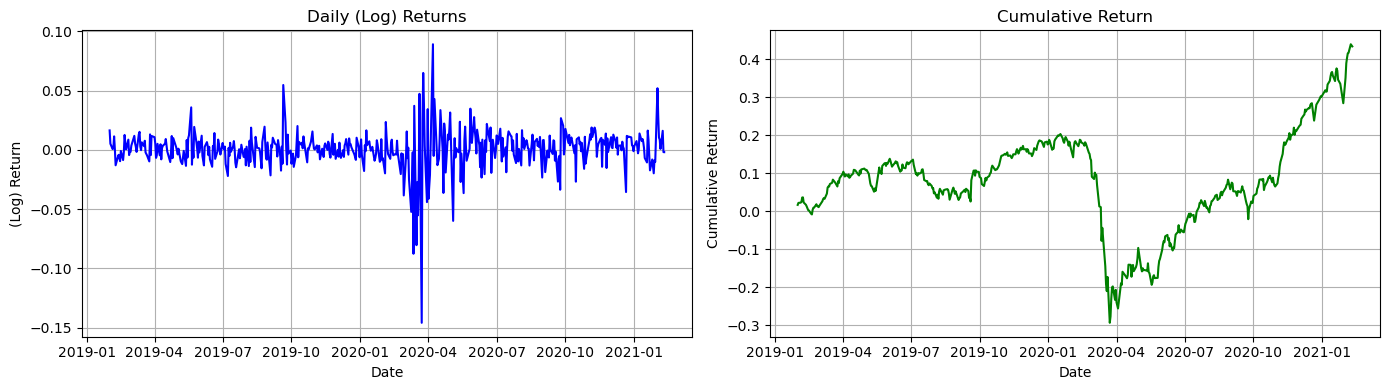

In [10]:
print("== Return and cumulative return is stress period (2019-01-31 to 2021-02-10)==")
plot_return(portfolio_return_stress)

In [11]:
def fit_test(returns):
    print("Summary statistics:")
    print(f"Mean: {returns.mean()}")
    print(f"Std Dev: {returns.std()}")
    print(f"Skewness: {skew(returns)}")
    print(f"Kurtosis: {kurtosis(returns)}")


    mu_norm, std_norm = norm.fit(returns)
    df_t, mu_t, std_t = t.fit(returns, floc=0)

    print(f"Normal fit: mu = {mu_norm:.6f}, std = {std_norm:.6f}")
    print(f"Student-t fit: df = {df_t:.2f}, mu = {mu_t:.6f}, std = {std_t:.6f}")


    returns_sorted = np.sort(returns)
    quantiles = np.linspace(0.01, 0.99, len(returns_sorted))


    norm_theoretical = norm.ppf(quantiles, loc=mu_norm, scale=std_norm)
    t_theoretical = t.ppf(quantiles, df=df_t, loc=mu_t, scale=std_t)


    r2_norm = r2_score(returns_sorted, norm_theoretical)
    r2_t = r2_score(returns_sorted, t_theoretical)

    print(f"R^2 for Normal fit: {r2_norm:.4f}")
    print(f"R^2 for Student-t fit: {r2_t:.4f}")


    ecdf = ECDF(returns)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))


    sns.histplot(returns, bins=50, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Histogram of Portfolio Log Returns")

    # ECDF
    axes[0, 1].plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
    axes[0, 1].set_title("Empirical CDF of Log Returns")
    axes[0, 1].set_xlabel("Log Return")
    axes[0, 1].set_ylabel("ECDF")


    sm.qqplot(returns, dist=norm, line='45', fit=True, ax=axes[1, 0])
    axes[1, 0].set_title(f'QQ-Plot against Normal\nR^2 = {r2_norm:.4f}')


    sm.qqplot(returns, dist=t, distargs=(df_t,), line='45', fit=True, ax=axes[1, 1])
    axes[1, 1].set_title(f'QQ-Plot against Student-t\nR^2 = {r2_t:.4f}')


    plt.tight_layout()
    #plt.savefig("normal-t-fit-r2.png")
    plt.show()

==Goodness of fit test on the returns in calm period==
Summary statistics:
Mean: 0.0013030570945239547
Std Dev: 0.0059852681318541155
Skewness: 0.01949652520076532
Kurtosis: 0.17932613551996202
Normal fit: mu = 0.001303, std = 0.005973
Student-t fit: df = 33.36, mu = 0.000000, std = 0.005928
R^2 for Normal fit: 0.9875
R^2 for Student-t fit: 0.9426


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


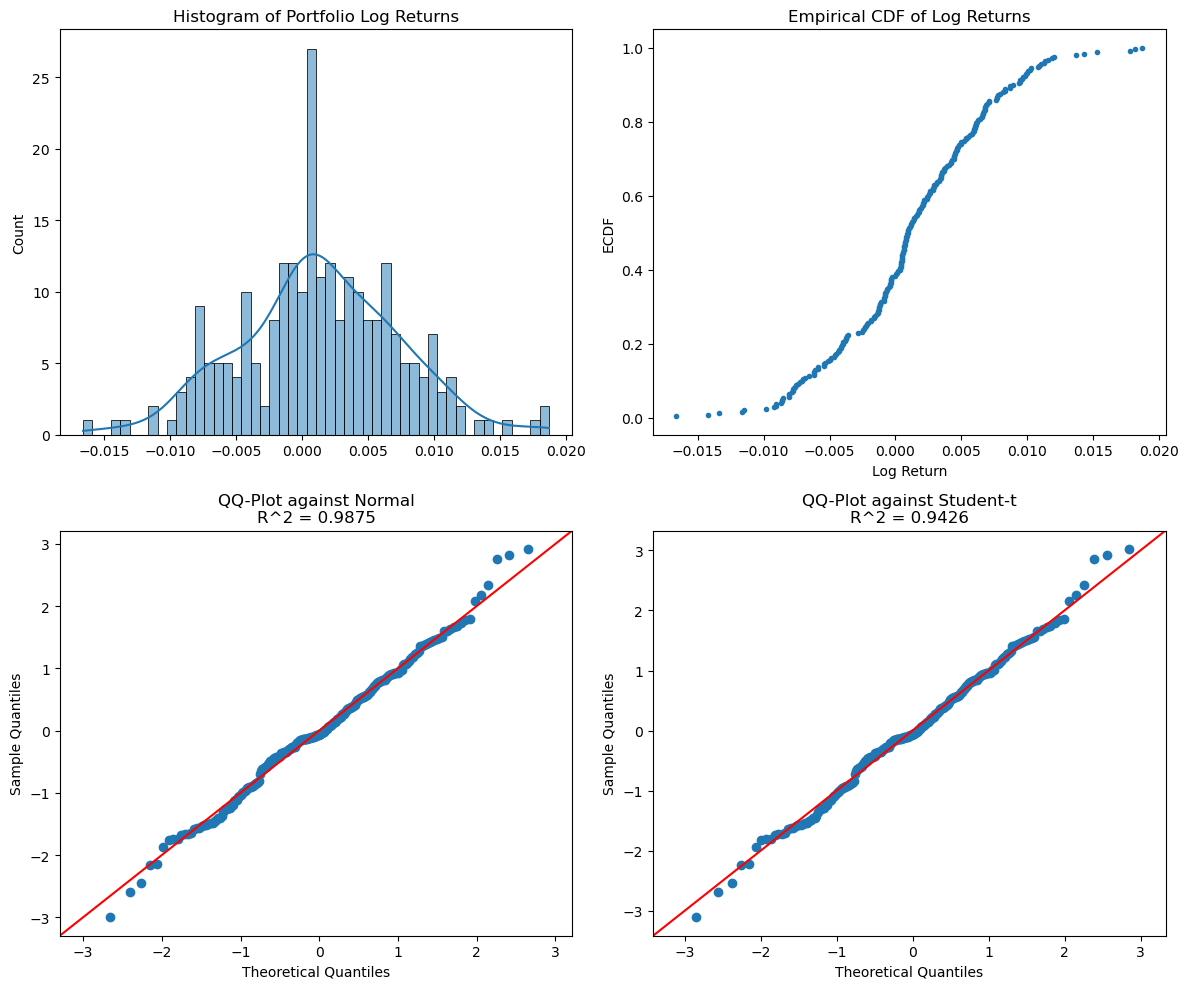

In [12]:
print("==Goodness of fit test on the returns in calm period==")
fit_test(portfolio_return_calm.tail(250))


Thus, during the calm period, the normal distribution provides a very good fit to the data, with an $R^2 \approx 0.99$.

==Goodness of fit test on the returns in stress period==
Summary statistics:
Mean: 0.001036015300649168
Std Dev: 0.021042699305316007
Skewness: -1.7116387743850794
Kurtosis: 12.047722676809789
Normal fit: mu = 0.001036, std = 0.021001
Student-t fit: df = 2.37, mu = 0.000000, std = 0.010765
R^2 for Normal fit: 0.7888
R^2 for Student-t fit: 0.8788


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


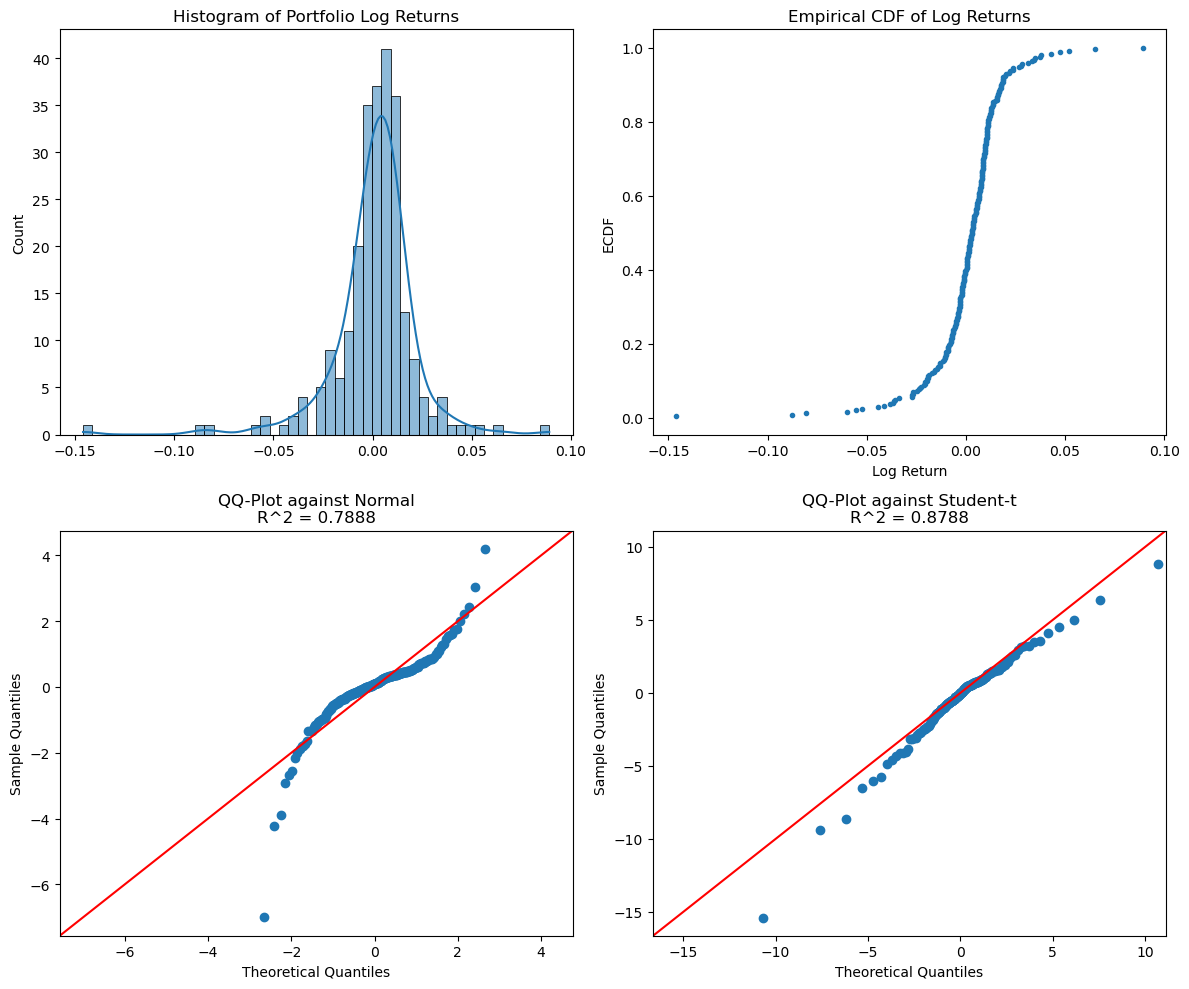

In [13]:
print("==Goodness of fit test on the returns in stress period==")
fit_test(portfolio_return_stress.tail(250))


During the stress period, returns were highly left-skewed and exhibited heavy tails (skewness = -1.71, kurtosis = 12.05). The normal distribution fit the data poorly ( $R^2 = 0.79$ ), while the Student-t distribution provided a significantly better fit ( $R^2 = 0.88$
), capturing the tail risk more effectively.

## VaR computation

Using a 250-day rolling window, we computed Value-at-Risk (VaR) with five methods: `Historical Simulation`, `Variance-Covariance`, `Monte Carlo`, `EWMA`, and `GARCH`, at multiple confidence levels (90%, 95%, 97%, and 99%), and backtested them separately over calm and stressed market periods.

Function to calculate VaR using Historical Simulation

In [14]:

def calculate_var_historical(portfolio,confidence_level):
    VaR_hist=[np.percentile(portfolio,100-cl) for cl in confidence_level]
    return VaR_hist
    

Function to calculate VaR using Variance-Covariance method

In [15]:

def calculate_var_varcov(portfolio,confidence_level):
    portfolio_mean=portfolio.mean()
    portfolio_std=portfolio.std()
    VaR_varcov=[stats.norm.ppf(1-cl/100)*portfolio_std+portfolio_mean for cl in confidence_level]
    return VaR_varcov
    

Function to calculate VaR using Monte Carlo Simulation

In [16]:

def calculate_var_monte_carlo(stock_return,weights,confidence_level,num_simulations=10**4):

    volatility = stock_return.std()
    drift=stock_return.mean()-0.5*(volatility**2)
    
    # Generate correlated random returns using Cholesky decomposition
    corr_matrix=stock_return.corr()
    cholesky_factor=scipy.linalg.cholesky(corr_matrix,lower=True)
    
    random_returns=np.random.normal(size=(len(weights),num_simulations))
    correlated_random_returns=np.dot(cholesky_factor,random_returns)
    
    simulated_returns=drift.values[:,None]+volatility.values[:,None]*correlated_random_returns
    simulated_portfolio_returns=np.dot(weights,simulated_returns)

    VaR_mc=[np.percentile(simulated_portfolio_returns, 100 - cl) for cl in confidence_level]
    
    return VaR_mc
    

Function to calculate VaR using EWMA

In [17]:

def calculate_var_ewma(portfolio,confidence_level):
    lambda_ = 0.94
    portfolio_mean = portfolio.mean()
    portfolio_std_sq = portfolio.var()
    predicted_sigma_2 = lambda_ * portfolio_std_sq + (1 - lambda_) * portfolio.iloc[-1]**2
    
    
    VaR_ewma=[stats.norm.ppf(1-cl/100) * np.sqrt(predicted_sigma_2) + portfolio_mean for cl in confidence_level]
    return VaR_ewma
    

Function to calculate VaR using GARCH

In [18]:
def calculate_var_garch(portfolio, confidence_level):
    dmeaned_portfolio = portfolio - portfolio.mean()
    model = arch_model(dmeaned_portfolio * 100, vol='Garch', p=1, q=1)
    garch_res = model.fit(disp='off')
    forecast = garch_res.forecast(horizon=1)
    sigma_t = np.sqrt(forecast.variance.iloc[-1, 0]) / 100
    VaR_garch=[stats.norm.ppf(1-cl/100) * sigma_t + portfolio.mean() for cl in confidence_level]
    return VaR_garch
    

In [19]:

confidence_level=[90,95,97,99]
window_size=250


In [20]:
def VaR_computation (stock_returns, weightage, confidence_level, window_size):
    
    portfolio_return = stock_returns @ weightage
    
    VaR_hist_portfolio = []
    VaR_varcov_portfolio = []
    VaR_mc_portfolio = []
    VaR_ewma_portfolio = []
    VaR_garch_portfolio = []


    for i in range(window_size, len(portfolio_return)):
        VaR_hist_portfolio.append(calculate_var_historical(portfolio_return[i-window_size:i],confidence_level))
        VaR_varcov_portfolio.append(calculate_var_varcov(portfolio_return[i-window_size:i],confidence_level))
        VaR_mc_portfolio.append(calculate_var_monte_carlo(stock_returns[i-window_size:i],sensex_weightage,confidence_level))
        VaR_ewma_portfolio.append(calculate_var_ewma(portfolio_return[i-window_size:i],confidence_level))
        VaR_garch_portfolio.append(calculate_var_garch(portfolio_return[i-window_size:i],confidence_level))

    portfolio_metrics=pd.DataFrame(
        data={"Actual return":portfolio_return[window_size:],},
        index= portfolio_return.index[window_size:]
        )


    for i,cl in enumerate(confidence_level):
        portfolio_metrics["VaR_hist "+str(cl)+"%"]=[x[i] for x in VaR_hist_portfolio]
        portfolio_metrics["VaR_varcov "+str(cl)+"%"]=[x[i] for x in VaR_varcov_portfolio]
        portfolio_metrics["VaR_mc "+str(cl)+"%"]=[x[i] for x in VaR_mc_portfolio]
        portfolio_metrics["VaR_ewma "+str(cl)+"%"]=[x[i] for x in VaR_ewma_portfolio]
        portfolio_metrics["VaR_garch "+str(cl)+"%"]=[x[i] for x in VaR_garch_portfolio]

    fig = portfolio_metrics[["Actual return", "VaR_hist 99%", "VaR_varcov 99%", "VaR_mc 99%","VaR_ewma 99%", "VaR_garch 99%"]].plot(figsize=(12,5))
    fig.set_xlabel("Date")
    fig.set_ylabel("Return")
    fig.grid(True)
    plt.title("VaR vs Actual Returns (in 2022)")
    plt.tight_layout()
    plt.show()

    (total_observations,tot_col)=portfolio_metrics.shape
    model_violation=[(portfolio_metrics.iloc[:, i] > portfolio_metrics.iloc[:, 0]).sum() for i in range(1,tot_col)]
    expected_violation=[round(total_observations*(1-(cl/100))) for cl in confidence_level]

    violation_data=np.array(model_violation).reshape(len(confidence_level), 5)
    violation_summary=pd.DataFrame(violation_data, columns=["Historical", "Var-Cov", "Monte-Carlo", "EWMA", "GARCH"],index=[str(x)+"%" for x in confidence_level])
    violation_summary["Exp violation"]=expected_violation
    
    return(violation_summary)



### VaR computation in normal market condition


== Violations of VaR in the calm period==


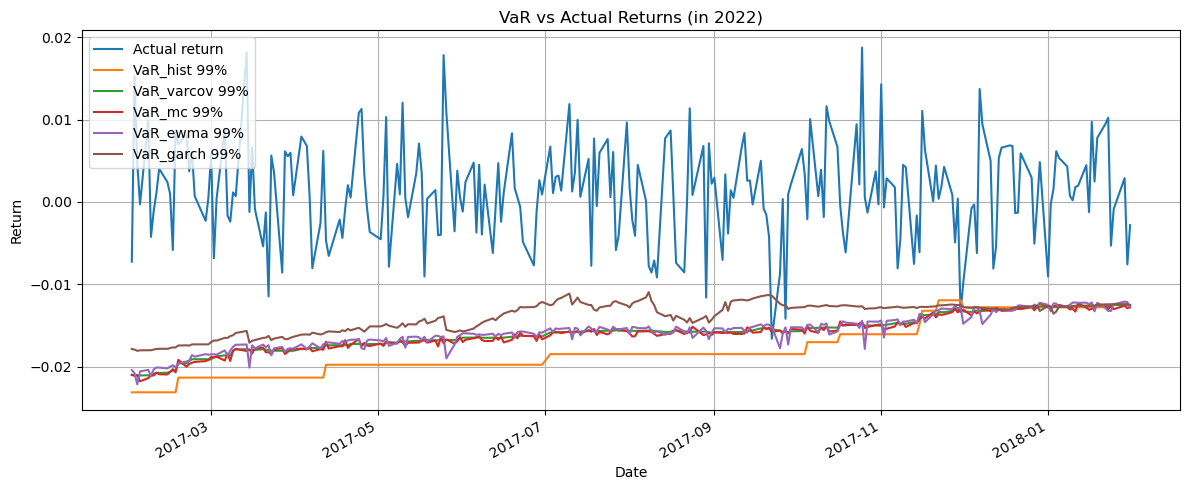

In [21]:
print("== Violations of VaR in the calm period==")
violation_summary_calm = VaR_computation(returns_calm, sensex_weightage, confidence_level, window_size)

### Violation Ratio in VaR Backtesting

The *Violation Ratio (VR)* checks if the actual number of VaR breaches aligns with expectations:
<br> $VR = \frac{x}{n \cdot \alpha}$

where:  
- $x$=Actual VaR breaches  
- $n$=Total observations  
- $\alpha$=VaR confidence level (e.g., for 99% VaR,=0.01).

**Interpretation:**
- $VR \approx 1$: Well-calibrated model  
- $VR>1$: Underestimates risk (too optimistic)  
- $VR < 1$: Overestimates risk (too conservative)
- Commonly, violation ratio in the range of $[0.8,1.2]$ considered as good. 


### The Kupiec Test:
<br> Also known as the Proportion of Failures (POF) Test, is a statistical test used in Value-at-Risk (VaR) backtesting to verify whether the observed violations (losses exceeding VaR) occur at the expected frequency. It is based on a likelihood ratio (LR) test. <br> The null hypothesis $H_0$ assumes that the proportion of VaR violations matches the expected probability $\alpha$: <br> where:
- $p = \frac{x}{n}$ is the observed proportion of violations,
- $x$ is the number of observed VaR breaches,
- $n$ is the total number of observations,
- $\alpha$ is the expected violation rate (e.g., for 99\% VaR,  $\alpha$ = 0.01).
<br> The *Kupiec likelihood ratio statistic* is given by:
<br> $LR_{POF} = -2 \log \left( \frac{ (1 - \alpha)^{n - x} \alpha^x }{ (1 - p)^{n - x} p^x } \right)$

<br> Under the null hypothesis, $LR_{POF}$ follows a chi-square distribution with one degree of freedom.

<br> Generally, if p-value $> 0.05$ (that is at 95\% confidence level), we fail to reject $H_0$, indicating that the VaR model is correctly calibrated.



In [22]:
def calculate_kupiec_test_stat(violations, tot_obs, tot_col, confidence_level, row, col):
    expected_prob = 1-(confidence_level[row]/100)
    violation_no = violations.iloc[row,col]
    violation_prob = violation_no/tot_obs
    if violation_prob == 0:
        return 0
    LR = -2*np.log((((1-expected_prob)/(1-violation_prob)) ** (tot_obs - violation_no)) *((expected_prob/violation_prob) ** violation_no))
    p_value = 1-chi2.cdf(LR, df=1)
    return p_value

In [23]:
def violation_test( violations, tot_obs, tot_col, confidence_level):
    print("== Number of violations==")
    print(violations)
    
    divisors = [tot_obs*(1-(cl/100)) for cl in confidence_level]
    violation_ratio = violations.iloc[:,:tot_col].div(divisors,axis=0)
    print("== Violation Ratios ==")
    print(violation_ratio)

    kupiec_test_p_value = pd.DataFrame(index=violation_ratio.index, columns=violation_ratio.columns)
    
    for i in range(violation_ratio.shape[0]):  
        for j in range(violation_ratio.shape[1]):  
            kupiec_test_p_value.iloc[i, j] = calculate_kupiec_test_stat(violations, tot_obs, tot_col, confidence_level, i, j)

    print("== Kupiec POF test p-value ==")
    print(kupiec_test_p_value)


                   

### Violation analysis in the calm period

In [24]:
violation_test( violation_summary_calm, 250, 5, confidence_level)

== Number of violations==
     Historical  Var-Cov  Monte-Carlo  EWMA  GARCH  Exp violation
90%          21       16           14    15     22             25
95%           6        6            6     5     10             13
97%           3        3            3     3      4              8
99%           1        2            2     2      3              3
== Violation Ratios ==
     Historical  Var-Cov  Monte-Carlo  EWMA     GARCH
90%        0.84     0.64         0.56   0.6  0.880000
95%        0.48     0.48         0.48   0.4  0.800000
97%        0.40     0.40         0.40   0.4  0.533333
99%        0.40     0.80         0.80   0.8  1.200000
== Kupiec POF test p-value ==
    Historical   Var-Cov Monte-Carlo      EWMA     GARCH
90%   0.387157  0.043545    0.012113  0.023744  0.519365
95%   0.036606  0.036606    0.036606  0.013738  0.452912
97%   0.058295  0.058295    0.058295  0.058295  0.155096
99%   0.278071  0.741933    0.741933  0.741933  0.757988


#### Violation Ratio analysis:

- All methods for calculating VaR perform reasonably well in calm period, except at few places VaR is over estimated.

## Compute VaR in the stressed period

== Violations of VaR in the stress period==


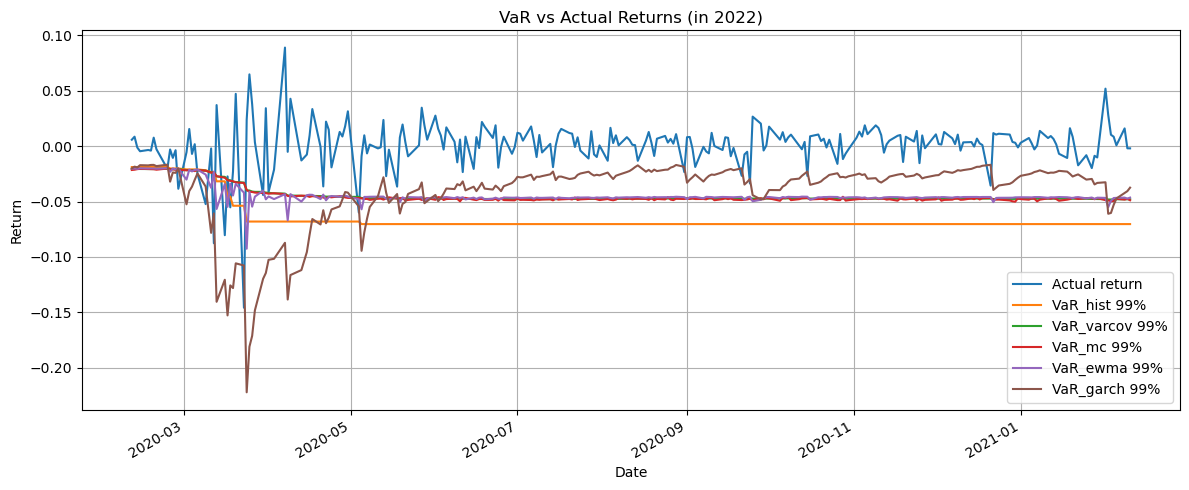

In [25]:
print("== Violations of VaR in the stress period==")
violation_summary_calm = VaR_computation(returns_stress, sensex_weightage, confidence_level, window_size)

### VaR computation in stressed market

In [26]:
violation_test( violation_summary_calm, window_size, 5, confidence_level)

== Number of violations==
     Historical  Var-Cov  Monte-Carlo  EWMA  GARCH  Exp violation
90%          31       20           20    18     27             25
95%          20       16           16    15     17             13
97%          14       12           12    12     14              8
99%           8        9           10    10     12              3
== Violation Ratios ==
     Historical  Var-Cov  Monte-Carlo  EWMA     GARCH
90%    1.240000     0.80         0.80  0.72  1.080000
95%    1.600000     1.28         1.28  1.20  1.360000
97%    1.866667     1.60         1.60  1.60  1.866667
99%    3.200000     3.60         4.00  4.00  4.800000
== Kupiec POF test p-value ==
    Historical   Var-Cov Monte-Carlo      EWMA     GARCH
90%   0.220926  0.276431    0.276431   0.12216  0.676821
95%   0.044446  0.329374    0.329374  0.481239  0.214575
97%   0.031015  0.124154    0.124154  0.124154  0.031015
99%    0.00542  0.001382    0.000319  0.000319  0.000013


#### Conclusion from violations analysis:

- All the methods failed at 99% confidence level, suggesting none of the models adequately captured extreme tail risk, particularly during stressed market conditions.

## Return Distribution and Extreme Value Theory Fitting

We analyzed the portfolio returns over the entire period (2015–2024) by fitting both the normal and Student-t distributions, and additionally modeled the tail behavior using the Generalized Pareto Distribution (GPD).

Summary statistics:
Mean: 0.0005958306937687705
Std Dev: 0.010758955634559374
Skewness: -1.4641806932438204
Kurtosis: 21.844635085794962
Normal fit: mu = 0.000596, std = 0.010757
Student-t fit: df = 3.77, mu = 0.000000, std = 0.007101
R^2 for Normal fit: 0.8331
R^2 for Student-t fit: 0.8611


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


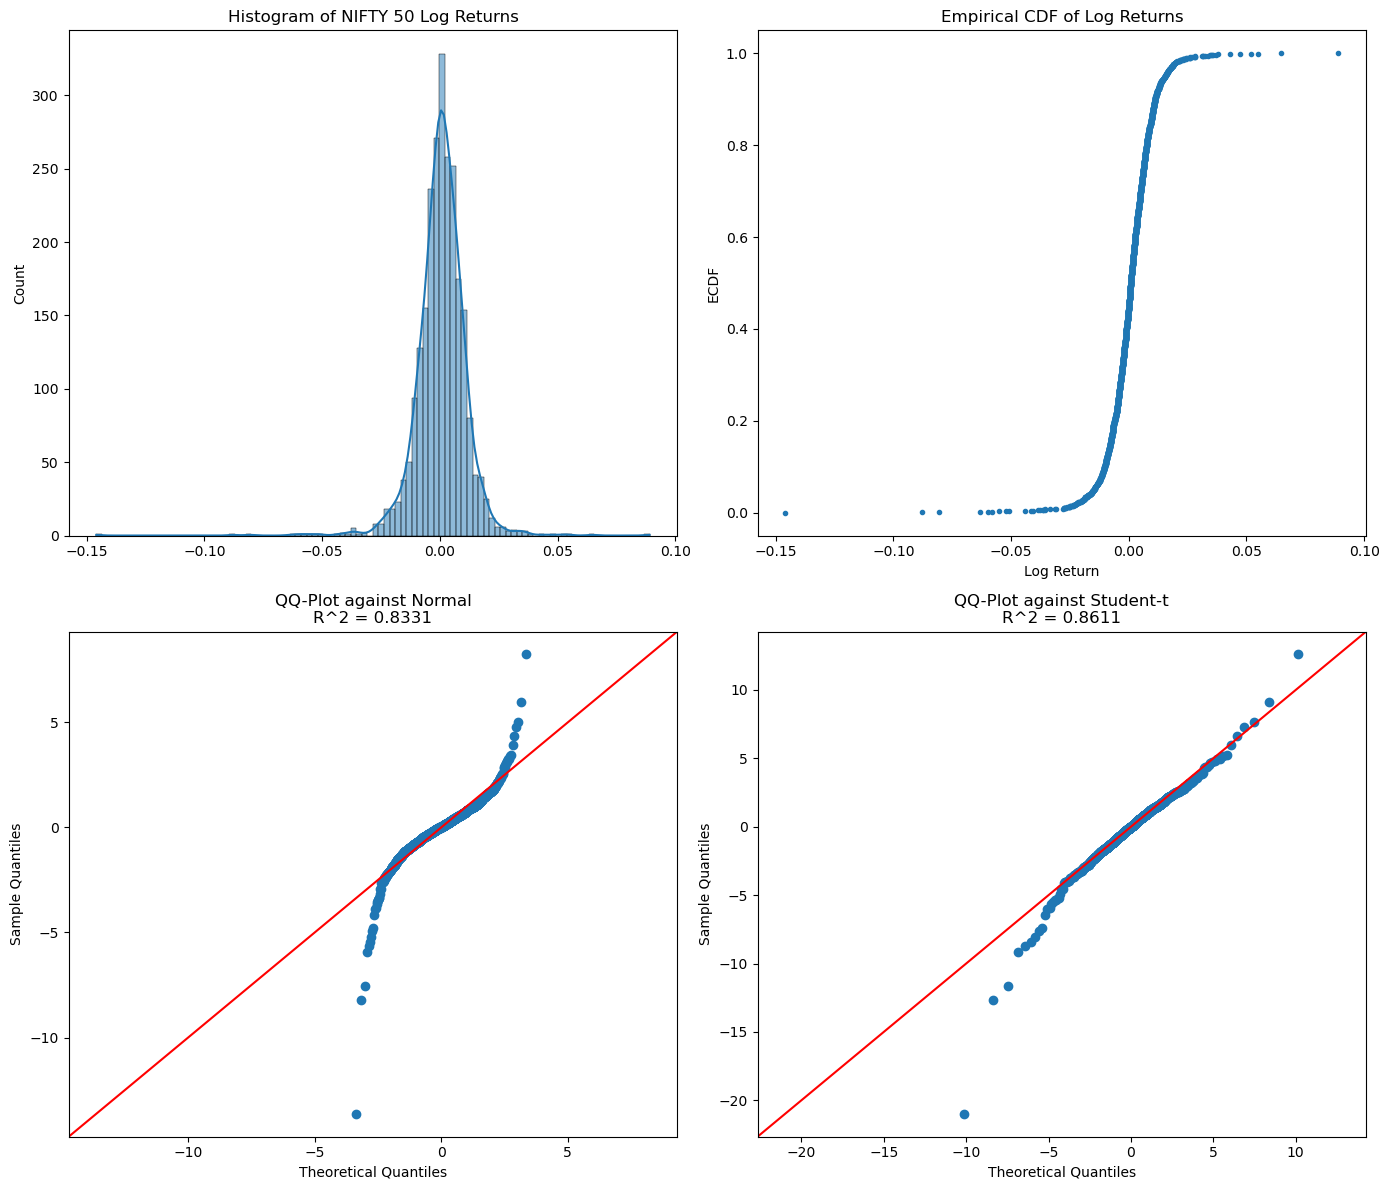

In [27]:
returns = portfolio_return.copy()

print("Summary statistics:")
print(f"Mean: {returns.mean()}")
print(f"Std Dev: {returns.std()}")
print(f"Skewness: {skew(returns)}")
print(f"Kurtosis: {kurtosis(returns)}")


mu_norm, std_norm = norm.fit(returns)
df_t, mu_t, std_t = t.fit(returns, floc=0)

print(f"Normal fit: mu = {mu_norm:.6f}, std = {std_norm:.6f}")
print(f"Student-t fit: df = {df_t:.2f}, mu = {mu_t:.6f}, std = {std_t:.6f}")


returns_sorted = np.sort(returns)
quantiles = np.linspace(0.01, 0.99, len(returns_sorted))


norm_theoretical = norm.ppf(quantiles, loc=mu_norm, scale=std_norm)
t_theoretical = t.ppf(quantiles, df=df_t, loc=mu_t, scale=std_t)


r2_norm = r2_score(returns_sorted, norm_theoretical)
r2_t = r2_score(returns_sorted, t_theoretical)

print(f"R^2 for Normal fit: {r2_norm:.4f}")
print(f"R^2 for Student-t fit: {r2_t:.4f}")


ecdf = ECDF(returns)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))


sns.histplot(returns, bins=100, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histogram of NIFTY 50 Log Returns")

# ECDF
axes[0, 1].plot(ecdf.x, ecdf.y, marker='.', linestyle='none')
axes[0, 1].set_title("Empirical CDF of Log Returns")
axes[0, 1].set_xlabel("Log Return")
axes[0, 1].set_ylabel("ECDF")


sm.qqplot(returns, dist=norm, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title(f'QQ-Plot against Normal\nR^2 = {r2_norm:.4f}')


sm.qqplot(returns, dist=t, distargs=(df_t,), line='45', fit=True, ax=axes[1, 1])
axes[1, 1].set_title(f'QQ-Plot against Student-t\nR^2 = {r2_t:.4f}')

plt.tight_layout()
#plt.savefig("normal-t-fit-r2.png")
plt.show()

Conclusions: The Student-t distribution fits the (SENSEX weightage) portfolio log returns better than the Normal distribution, as indicated by a higher $R^2$ (0.86 vs. 0.83). Its low degrees of freedom $\approx$ 4 ) capture the observed heavy tails in the data (kurtosis $\approx$ 21.84), making it more suitable for modeling extreme returns and tail risk.

R² for GPD left-tail fit: 0.9026


/home/nirmal/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


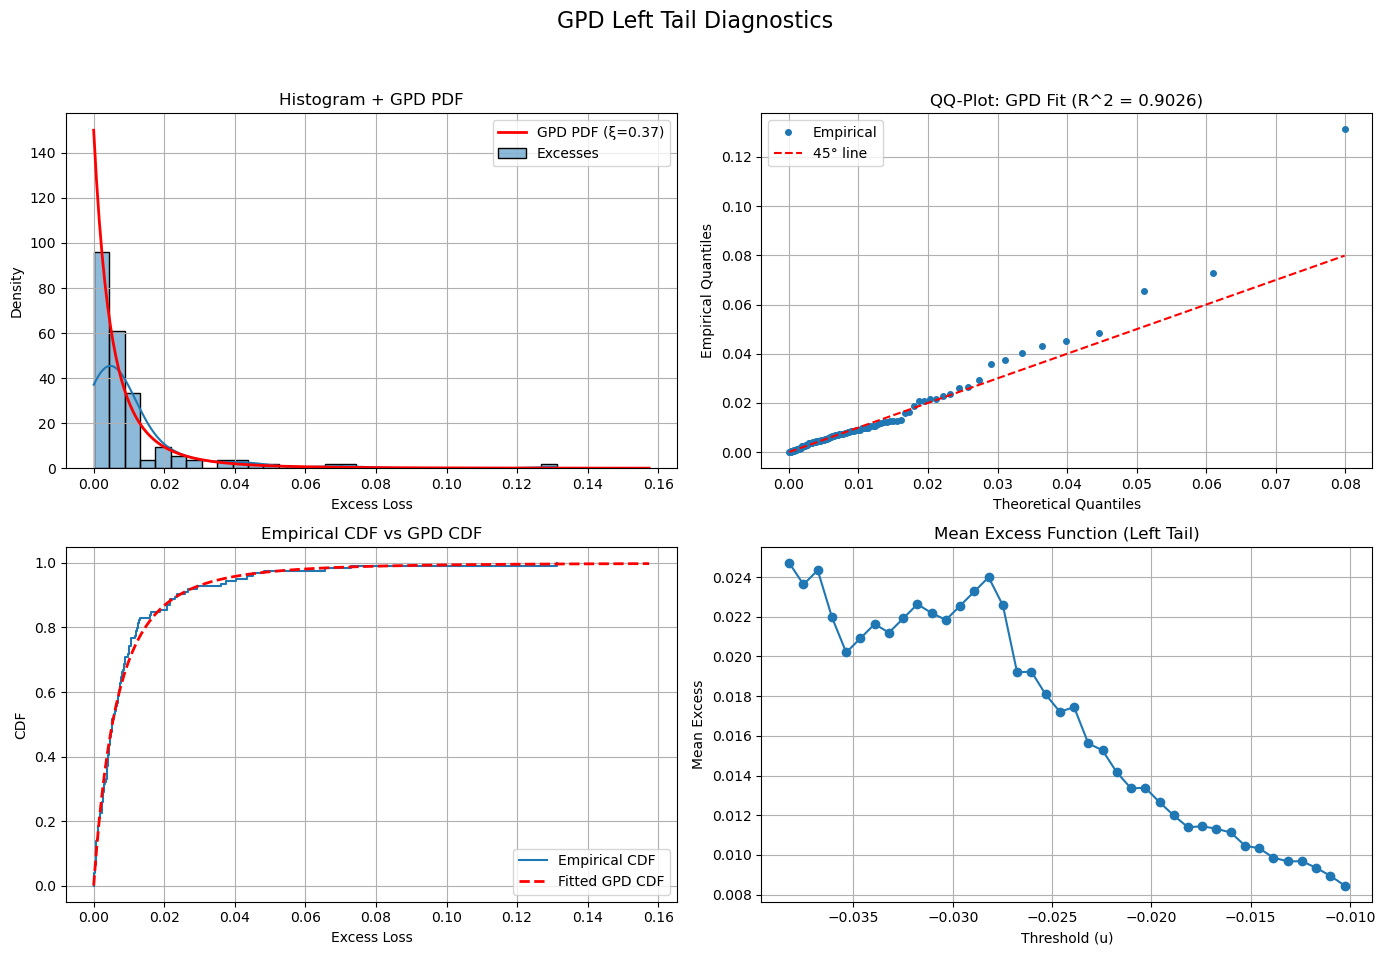

In [28]:
threshold_left = np.percentile(returns, 5)
excess_left = threshold_left - returns[returns < threshold_left]


shape_left, loc_left, scale_left = genpareto.fit(excess_left, floc=0)

emp_excess = np.sort(excess_left)
quantiles = np.linspace(0.01, 0.99, len(emp_excess))
theor_excess = genpareto.ppf(quantiles, c=shape_left, loc=0, scale=scale_left)


r2_gpd = r2_score(emp_excess, theor_excess)
print(f"R² for GPD left-tail fit: {r2_gpd:.4f}")


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("GPD Left Tail Diagnostics", fontsize=16)


x = np.linspace(0, max(excess_left) * 1.2, 200)
pdf_fitted = genpareto.pdf(x, c=shape_left, loc=0, scale=scale_left)
sns.histplot(excess_left, bins=30, stat='density', ax=axes[0, 0], label='Excesses', kde=True)
axes[0, 0].plot(x, pdf_fitted, 'r-', lw=2, label=f'GPD PDF (ξ={shape_left:.2f})')
axes[0, 0].set_title("Histogram + GPD PDF")
axes[0, 0].set_xlabel("Excess Loss")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()
axes[0, 0].grid(True)


emp_excess = np.sort(excess_left)
theor_q = genpareto.ppf(np.linspace(0.01, 0.99, len(emp_excess)), c=shape_left, loc=0, scale=scale_left)
axes[0, 1].plot(theor_q, emp_excess, 'o', markersize=4, label='Empirical')
axes[0, 1].plot(theor_q, theor_q, 'r--', label='45° line')
axes[0, 1].set_title(f"QQ-Plot: GPD Fit (R^2 = {r2_gpd:.4f})")
axes[0, 1].set_xlabel("Theoretical Quantiles")
axes[0, 1].set_ylabel("Empirical Quantiles")
axes[0, 1].legend()
axes[0, 1].grid(True)


ecdf = ECDF(excess_left)
cdf_vals = genpareto.cdf(x, c=shape_left, loc=0, scale=scale_left)
axes[1, 0].step(ecdf.x, ecdf.y, where='post', label='Empirical CDF')
axes[1, 0].plot(x, cdf_vals, 'r--', lw=2, label='Fitted GPD CDF')
axes[1, 0].set_title("Empirical CDF vs GPD CDF")
axes[1, 0].set_xlabel("Excess Loss")
axes[1, 0].set_ylabel("CDF")
axes[1, 0].legend()
axes[1, 0].grid(True)


thresholds = np.linspace(np.percentile(returns, 0.5), np.percentile(returns, 10), 40)
mean_excess = []
for u in thresholds:
    tail = returns[returns < u]
    if len(tail) > 0:
        mean_excess.append(np.mean(u - tail))
    else:
        mean_excess.append(np.nan)

axes[1, 1].plot(thresholds, mean_excess, marker='o')
axes[1, 1].set_title("Mean Excess Function (Left Tail)")
axes[1, 1].set_xlabel("Threshold (u)")
axes[1, 1].set_ylabel("Mean Excess")
axes[1, 1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.savefig("gpd_fit.png")
plt.show()


We modeled the left tail of our (SENSEX weightage) portfolio log returns using a Generalized Pareto Distribution (GPD) for excess losses beyond the 5th percentile. The fitted GPD aligns well with the empirical histogram and ECDF, and the QQ plot shows a good match for most quantiles, with minor underestimation of extreme losses. The mean excess function is approximately linear above the threshold, supporting the use of GPD in this region. The goodness-of-fit is further confirmed by a high $R^2$ value of 0.90. Overall, the GPD is a reasonable choice for modeling left-tail risk and estimating high-confidence risk measures like Value at Risk (VaR).

## EVT based VaR computation and backtest

In [29]:
def calculate_var_evt(data, confidence_level, threshold_pct):
    threshold = np.percentile(data, threshold_pct)
    tail_data = threshold - data[data < threshold]  # excesses



    shape, loc, scale = genpareto.fit(tail_data, floc=0)
    p_tail = len(tail_data) / len(data)

    VaR_evt = [threshold - genpareto.ppf(1 - (1 - cl/100) / p_tail, c=shape, loc=0, scale=scale) for cl in confidence_level]
    return VaR_evt

In [30]:
def calculate_var_garch_evt(data, confidence_level, threshold_pct):
    demeaned_data = data - data.mean()
    model = arch_model(demeaned_data * 100, vol='Garch', p=1, q=1, dist = 't')
    res = model.fit(update_freq=0, disp='off')

    cond_vol = res.conditional_volatility / 100
    std_resids = (demeaned_data / cond_vol.shift(1)).dropna()

    var_std = calculate_var_evt(std_resids, confidence_level, threshold_pct)

    forecast = res.forecast(horizon=1)
    sigma_forecast = np.sqrt(forecast.variance.values[-1, 0]) / 100 
    
    var_actual = np.multiply(sigma_forecast , var_std) + data.mean()

    return var_actual


We use the same stressed market period (COVID crisis) to compute the 99% Value at Risk (VaR), applying a 250-day rolling window. The computed VaR is then backtested to evaluate the model's performance under extreme market conditions.

In [31]:

confidence_level_ext = [99]
threshold_pct = 10
window_size = 250


In [32]:
VaR_evt_portfolio = []
VaR_garch_evt_portfolio = []

for i in range(window_size, len(portfolio_return_stress)):
    VaR_evt_portfolio.append(calculate_var_evt(portfolio_return_stress[i-window_size:i], confidence_level_ext, threshold_pct))
    VaR_garch_evt_portfolio.append(calculate_var_garch_evt(portfolio_return_stress[i-window_size:i],confidence_level_ext, threshold_pct))
    

In [33]:
portfolio_metrics_ext=pd.DataFrame(
    data={"Actual return": portfolio_return_stress[window_size:],
         },
    index = portfolio_return_stress.index[window_size:]
)

for i,cl in enumerate(confidence_level_ext):
    portfolio_metrics_ext["VaR_evt "+str(cl)+"%"]=[x[i] for x in VaR_evt_portfolio]
    portfolio_metrics_ext["VaR_garch_evt "+str(cl)+"%"]=[x[i] for x in VaR_garch_evt_portfolio]



In [34]:
(total_observations,tot_col)=portfolio_metrics_ext.shape
model_violation=[(portfolio_metrics_ext.iloc[:, i] > portfolio_metrics_ext.iloc[:, 0]).sum() for i in range(1,tot_col)]
expected_violation=[round(total_observations*(1 - cl/100 )) for cl in confidence_level_ext]


violation_summary=pd.DataFrame(np.array(model_violation).reshape(1,2), columns=["EVT", "GARCH+EVT"], index = [str(x)+"%" for x in confidence_level_ext])
violation_summary["Exp violation"]=expected_violation

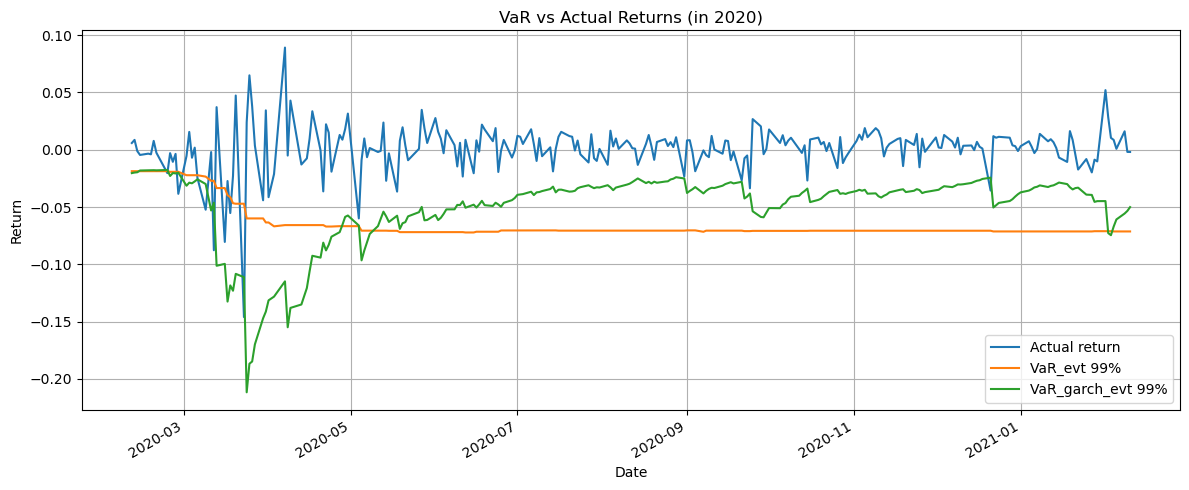

In [35]:
fig = portfolio_metrics_ext[["Actual return", "VaR_evt 99%", "VaR_garch_evt 99%"]].plot(figsize=(12,5))
fig.set_xlabel("Date")
fig.set_ylabel("Return")
fig.grid(True)
plt.title("VaR vs Actual Returns (in 2020)")
plt.tight_layout()
plt.show()


In [36]:
violation_test( violation_summary, window_size, 2, confidence_level_ext)

== Number of violations==
     EVT  GARCH+EVT  Exp violation
99%    8          6              3
== Violation Ratios ==
     EVT  GARCH+EVT
99%  3.2        2.4
== Kupiec POF test p-value ==
         EVT GARCH+EVT
99%  0.00542  0.059354


## Conclusion: 99% VaR Backtesting and Basel Traffic Light Interpretation

- We performed 99% VaR backtesting on portfolio returns for the year 2020, which was a stressed market period due to the COVID-19 crash.
- Observed number of violations over **250 trading days** are summarized below:

| Method               | Violations | Basel Zone |
|----------------------|------------|------|
| Historical           | 8         | $\colorbox{yellow}{Yellow Zone}$ |
| Variance-Covariance  | 9          | $\colorbox{yellow}{Yellow Zone}$ |
| Monte Carlo          | 9         | $\colorbox{yellow}{Yellow Zone}$ |
| EWMA                 | 10         | $\colorbox{red}{Red Zone }$ |
| GARCH                | 12         | $\colorbox{red}{Red Zone }$ |
| EVT                  | 8          | $\colorbox{yellow}{Yellow Zone}$ |
| GARCH + EVT          | 6          | $\colorbox{yellow}{Yellow Zone}$ |


### Basel Traffic Light Framework (for 250 observations):
- ** $\colorbox{green}{Green Zone}$**: 0-4 violations $\implies$ Model is acceptable
- ** $\colorbox{yellow}{Yellow Zone}$**: 5-9 violations $\implies$ Increased supervisory attention
- ** $\colorbox{red}{Red Zone }$**: 10 or more violations $\implies$ Model deemed inadequate

### Interpretation:
- All methods are in the **yellow or red zone** due to the stressed conditions.
- **GARCH + EVT**  had **only 6 violations**, lowest among all methods, placed in the **yellow zone**, suggesting better performance under tail risk.
- Volatility based models like **pure GARCH** and **EWMA** exceeded 10 violations, entering the **red zone** and failing to capture tail risk effectively.

### Final Takeaway:
- **EVT-enhanced models** demonstrate **improved robustness** in modeling extreme losses during stressed markets.
- These methods are better suited for risk management when extreme events are more probable.
